# Chapter 13 代码教学：轻量多模态大模型（M-LLM）
**目标：用最轻量的组件 + 极少数据，把“视觉编码器对齐到 LLM”的完整流程跑通，并做 ablation（有图 vs 无图）对比。**

---

## 你应该期待什么效果（非常重要）
这是一个 **教学用“原理演示版”**：  
- **我们只训练一个很小的对齐层（Projector/Prefix）**，冻结 CLIP（ViT）与 Qwen（LLM）。  
- 数据量很小（Flickr8k 里抽几百张），训练步数很少。  

因此：
1. **最低合格（课堂展示足够）**：  
   - `With image` 更像“图像描述/caption 风格”，具体名词更多。  
   - `LLM only` 更像纯语言闲聊/自述/模板，不稳定。  
   → 这说明：视觉 token 前缀通过 projector 注入，改变了 LLM 的生成分布（多模态核心机制）。
2. **效果提醒**：  
   - 输出不严格贴近 GT caption（grounding 更难，通常需要更多训练/更强结构/更强模型）。

---

## 核心原理一句话
**图像 → ViT 得到特征 → Projector 映射到 LLM hidden space → 作为“视觉前缀 token”拼到文本 token 前面 → LLM 继续做因果语言建模。**

## Cell 1：环境与随机种子
- 固定随机种子便于复现  
- 自动选择 device（cuda 优先）

In [13]:
import os, random
import torch
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", device)

# 可选：更强的可复现性（会稍慢）
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = cuda


## Cell 2：超参数（尽量少、但能看出差异）
- `NUM_VIS_TOKENS`：视觉前缀 token 数（8~32）
- `N_TRAIN`：训练样本数（演示用 256~1024 都可以）
- `EPOCHS`：训练轮数（2~5）

In [14]:
# ====== tiny demo hyperparams ======
NUM_VIS_TOKENS = 16     # 8~32；越大越慢但信息更足
N_TRAIN = 256           # 少量就够演示
N_VAL   = 16

BATCH = 4
EPOCHS = 2
LR = 5e-5
MAX_TEXT_LEN = 64       # 文本最大长度（prompt+caption）
GEN_MAX_NEW = 24        # 推理生成长度（控制输出更干净）

# 采样参数：比 greedy 更不复读，但别太大以免发散
TOP_P = 0.7
TEMPERATURE = 0.6

## Cell 3：加载最小数据集（Flickr8k 子集）
数据：image + caption_0..caption_4  
我们从 train 中随机抽取 `N_TRAIN` 做训练，`N_VAL` 做演示验证。

In [15]:
from datasets import load_dataset

ds = load_dataset("jxie/flickr8k")  # image + caption_0..caption_4
train_ds = ds["train"]

idx = list(range(len(train_ds)))
random.shuffle(idx)
train_idx = idx[:N_TRAIN]
val_idx   = idx[N_TRAIN:N_TRAIN+N_VAL]

train_small = train_ds.select(train_idx)
val_small   = train_ds.select(val_idx)

print(train_small)
print("example keys:", train_small[0].keys())

Dataset({
    features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
    num_rows: 256
})
example keys: dict_keys(['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'])


## Cell 4：视觉编码器（ViT / CLIP Vision）  
- 使用轻量视觉编码器 `openai/clip-vit-base-patch32`  
- 输出：`last_hidden_state`（含 CLS + patches）  
- 冻结参数：只训练 projector

In [16]:
from transformers import CLIPVisionModel, CLIPImageProcessor

vision_name = "openai/clip-vit-base-patch32"
image_processor = CLIPImageProcessor.from_pretrained(vision_name)
vision = CLIPVisionModel.from_pretrained(vision_name).to(device)
vision.eval()

for p in vision.parameters():
    p.requires_grad = False

print("vision loaded:", vision_name)
print("vision hidden size =", vision.config.hidden_size)

vision loaded: openai/clip-vit-base-patch32
vision hidden size = 768


## Cell 5：语言模型（LLM）  
选择轻量 LLM：`Qwen/Qwen2.5-0.5B-Instruct`  
- 冻结 LLM，仅用它做“条件语言建模”  
- **关键修正**：确保 tokenizer 有 `pad_token`（否则 padding 行为混乱）

In [17]:
from transformers import AutoTokenizer, AutoModelForCausalLM

llm_name = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(llm_name, use_fast=True)

# ✅ 关键：很多 Instruct tokenizer 没有 pad_token，必须设定
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

llm = AutoModelForCausalLM.from_pretrained(
    llm_name,
    torch_dtype=torch.float16 if device=="cuda" else torch.float32,
).to(device)

llm.eval()
for p in llm.parameters():
    p.requires_grad = False

llm_dtype = llm.get_input_embeddings().weight.dtype
print("llm loaded:", llm_name)
print("llm_dtype =", llm_dtype)
print("llm hidden size =", llm.config.hidden_size)
print("pad_token_id =", tokenizer.pad_token_id, "eos_token_id =", tokenizer.eos_token_id)

llm loaded: Qwen/Qwen2.5-0.5B-Instruct
llm_dtype = torch.float16
llm hidden size = 896
pad_token_id = 151643 eos_token_id = 151645


## Cell 6：图像 → patch tokens（冻结 ViT）
输出形状：`[B, S, vision_dim]`，其中 `S = 1(CLS) + patches`

In [18]:
@torch.no_grad()
def encode_image_to_patches(pil_images):
    inputs = image_processor(images=pil_images, return_tensors="pt").to(device)
    out = vision(**inputs)
    return out.last_hidden_state  # [B, S, vision_dim]

## Cell 7：Prefix-style Projector（核心：对齐层）
为什么用 Prefix？
- 直接把图像特征映射成 LLM hidden space 的若干 token（prefix tokens）
- 拼在文本 token 前面，LLM 就能把视觉信息当作“上下文”来用

实现：
- 用 CLS（全局语义）作为图像摘要
- MLP 映射到 `llm_dim`
- 复制成 `NUM_VIS_TOKENS` 个 prefix token，并加可学习位置向量（让每个 token 有差异）

In [19]:
class PrefixProjector(nn.Module):
    """
    PrefixProjector：把“图像编码器输出”映射成一段 LLM 可读的“视觉前缀 token”。

    思想：
      - ViT/CLIP 的输出是 [B, S, vision_dim] 的序列（含 CLS + patches）
      - LLM 需要 [B, T, llm_dim] 的 token embedding
      - 所以我们把图像压缩成一个全局向量（CLS），再映射到 llm_dim，
        然后扩展成 num_tokens 个“视觉 token”，拼到文本 token 前面。

    为什么要 num_tokens 个而不是 1 个？
      - 多个 token = 更大的“信息带宽”，LLM 通过自注意力可以从多个位置读取视觉信息
      - 同时每个 token 需要区分“位置/角色”，所以加入可学习位置向量 prefix_pos
    """

    def __init__(self, vision_dim: int, llm_dim: int, num_tokens: int):
        super().__init__()
        self.num_tokens = num_tokens

        # MLP：把 vision_dim（例如 768）映射到 llm_dim（例如 896）
        # 这里用两层 Linear + GELU，足够轻量
        self.mlp = nn.Sequential(
            nn.Linear(vision_dim, llm_dim),
            nn.GELU(),
            nn.Linear(llm_dim, llm_dim),
        )

        # 可学习的“前缀位置向量”
        # 形状 [V, D]：V = num_tokens，D = llm_dim
        # 作用：让第 0 个视觉 token、第 1 个视觉 token…在 embedding 空间中可区分
        self.prefix_pos = nn.Parameter(torch.randn(num_tokens, llm_dim) * 0.02)

    def forward(self, patches: torch.Tensor, llm_dtype: torch.dtype):
        """
        patches: [B, S, vision_dim]
          - B: batch size
          - S: 视觉序列长度（CLS + patch tokens），例如 1 + 49
          - vision_dim: CLIP-ViT 的 hidden size，例如 768

        llm_dtype:
          - LLM embedding 的 dtype（常见是 fp16 / bf16）
          - 重要：最终输出要转成 llm_dtype，否则后面和 LLM 做 matmul 会 dtype mismatch
        """

        # 1) 取 CLS token 作为“全局图像语义摘要”
        #    CLS 相当于对整张图的压缩表示（比只拿前几个 patch 稳定得多）
        #    cls: [B, vision_dim]
        cls = patches[:, 0, :]

        # 2) 映射到 LLM 的 hidden 维度
        #    - 先用 float() 保证 MLP 在 fp32 上算（更稳）
        #    - 再 to(llm_dtype) 适配 LLM（避免 dtype mismatch）
        #    base: [B, llm_dim]
        base = self.mlp(cls.float()).to(llm_dtype)

        # 3) 把一个全局向量扩展成 V 个 prefix token
        #    base: [B, 1, llm_dim] -> repeat -> [B, V, llm_dim]
        #    直观理解：让 LLM 看到 V 个“视觉 token 槽位”
        base = base[:, None, :].repeat(1, self.num_tokens, 1)

        # 4) 加上可学习位置向量，让每个视觉 token 有不同“身份”
        #    prefix_pos: [V, D] -> [1, V, D] broadcast 到 [B, V, D]
        #    out: [B, V, llm_dim]
        out = base + self.prefix_pos[None, :, :].to(llm_dtype)

        return out


# ===== instantiate projector =====
projector = PrefixProjector(
    vision_dim=vision.config.hidden_size,   # e.g. 768
    llm_dim=llm.config.hidden_size,         # e.g. 896
    num_tokens=NUM_VIS_TOKENS               # e.g. 16
).to(device)

print("projector params =", sum(p.numel() for p in projector.parameters()))
print("vision_dim =", vision.config.hidden_size)
print("llm_dim   =", llm.config.hidden_size)
print("num_vis_tokens =", NUM_VIS_TOKENS)


projector params = 1507072
vision_dim = 768
llm_dim   = 896
num_vis_tokens = 16


## Cell 8：构造训练 batch：`(vis_prefix + text) → LLM`  
训练目标：让 LLM 在看到 `PROMPT + caption` 时，学会利用 `vis_prefix` 生成 caption。

### 重点提示（容易“乱跑/跑偏/复述”的陷阱）
**padding token 不应参与 loss。**  
- HF CausalLM loss 主要看 `labels != -100`  
- attention_mask 为 0 并不会自动把 loss 置零  
➡️ 必须显式：`labels_text[attn_text==0] = -100`

In [20]:
PROMPT = "Describe the image in one sentence:"

def pick_caption(ex):
    k = random.randint(0, 4)
    return ex[f"caption_{k}"]

def build_inputs(pil_images, captions):
    """
    return:
      inputs_embeds: [B, (V + T), llm_dim]
      attention_mask: [B, (V + T)]
      labels: [B, (V + T)]
    """
    B = len(pil_images)

    # 1) vision patches (通常是 fp32)
    patches = encode_image_to_patches(pil_images)   # [B, S, vision_dim]
    vis_embeds = projector(patches, llm_dtype)      # ✅ [B, V, llm_dim]


    # 2) text tokens (embedding dtype = llm_dtype)
    texts = [f"{PROMPT} {cap}" for cap in captions]
    tok = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=64,
    ).to(device)

    input_ids = tok["input_ids"]                 # [B, T], long
    attn_text = tok["attention_mask"]            # [B, T], long
    text_embeds = llm.get_input_embeddings()(input_ids)  # [B, T, llm_dim], llm_dtype

    # 3) concat embeds（确保最终 inputs_embeds dtype = llm_dtype）
    inputs_embeds = torch.cat([vis_embeds, text_embeds], dim=1).to(llm_dtype)

    # attention_mask：用 long/bool，别用 float
    vis_attn = torch.ones(B, NUM_VIS_TOKENS, device=device, dtype=attn_text.dtype)  # long
    attention_mask = torch.cat([vis_attn, attn_text], dim=1)

    # 4) labels：视觉前缀 + prompt 部分 ignore，只训练 caption
    labels_text = input_ids.clone()
    labels_text[:] = -100

    prompt_ids = tokenizer(PROMPT, add_special_tokens=False).input_ids
    prompt_len = len(prompt_ids) + 1  # +1 for the extra space in f"{PROMPT} {cap}"

    for i in range(B):
        start = min(prompt_len, labels_text.size(1))
        labels_text[i, start:] = input_ids[i, start:]

    labels_vis = torch.full((B, NUM_VIS_TOKENS), -100, device=device, dtype=labels_text.dtype)
    labels = torch.cat([labels_vis, labels_text], dim=1)

    return inputs_embeds, attention_mask, labels


## Cell 9：训练（只训练 projector）
- 冻结 vision 与 llm  
- 训练 projector  
- 使用梯度裁剪避免小数据/较大 LR 时发散

In [21]:
def collate_fn(batch):
    images = [ex["image"] for ex in batch]
    caps = [pick_caption(ex) for ex in batch]
    return images, caps

train_loader = DataLoader(
    train_small,
    batch_size=BATCH,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=(device=="cuda"),
)

opt = torch.optim.AdamW(projector.parameters(), lr=5e-4, weight_decay=0.0)

llm.eval()
vision.eval()
projector.train()

for epoch in range(EPOCHS):
    pbar = tqdm(train_loader, desc=f"epoch {epoch}")
    for images, caps in pbar:
        inputs_embeds, attn_mask, labels = build_inputs(images, caps)
        out = llm(inputs_embeds=inputs_embeds, attention_mask=attn_mask, labels=labels)
        loss = out.loss

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(projector.parameters(), 1.0)
        opt.step()

        pbar.set_postfix(loss=float(loss.detach().cpu()))

projector.eval()
llm.eval()
print("done.")

epoch 1: 100%|██████████| 64/64 [01:01<00:00,  1.04it/s, loss=3.08]

done.


## Cell 10：推理（用 `generate`，避免手写 cache 的 deprecated 警告）
同一个 PROMPT：
- **With image**：`vis_prefix + PROMPT`
- **LLM only**：只有 `PROMPT`

为了输出更干净：
- 使用 `top_p` + `temperature` 采样（收紧参数避免发散）
- 生成长度限制 `GEN_MAX_NEW`
- decode 后只保留第一句

In [22]:
# Cell 10: manual greedy decoding (fixed dtype)
# 目标：不用 transformers.generate（避免黑盒），手写 “prefill + decode” 的 token-by-token 解码流程
# - With image：把视觉前缀 token（projector 输出）拼到文本 prompt embedding 前面
# - LLM only：只用文本 prompt，不注入视觉前缀
# 这样能清晰展示：视觉信息是怎么以“prefix token”的形式进入 LLM 的上下文的。

@torch.no_grad()
def _sample_top_p(logits, top_p=0.9, temperature=0.8):
    """
    nucleus sampling / top-p 采样（比纯 argmax 更少复读、更自然）
    输入：
      logits: [..., vocab_size]（通常来自 out.logits[:, -1, :]）
    输出：
      next_token_id: shape [...], dtype long（这里最后 squeeze(-1) 变成标量/向量）
    """

    # 1) temperature：控制随机性
    # - temperature < 1：更“保守”，更确定
    # - temperature > 1：更“发散”，更随机
    logits = logits / max(temperature, 1e-6)

    # 2) softmax -> 概率分布
    probs = F.softmax(logits, dim=-1)

    # 3) 对 vocab 概率降序排序
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)

    # 4) 计算 cumulative probability，用来找“概率质量前 top_p 的集合”
    cum = torch.cumsum(sorted_probs, dim=-1)

    # 5) keep mask：保留累计概率 <= top_p 的 token
    keep = cum <= top_p
    keep[..., 0] = True  # ✅ 至少保留 1 个 token（防止 top_p 太小导致全 False）

    # 6) 把不保留的 token 概率置 0，并重新归一化
    filtered_probs = sorted_probs * keep
    filtered_probs = filtered_probs / filtered_probs.sum(dim=-1, keepdim=True)

    # 7) 在“排序后的 token 空间”里抽样 1 个
    next_in_sorted = torch.multinomial(filtered_probs, num_samples=1)

    # 8) 映射回原 vocab id
    next_token = sorted_idx.gather(-1, next_in_sorted)

    return next_token.squeeze(-1)


@torch.no_grad()
def vlm_greedy_answer(pil_image, question, max_new_tokens=32, top_p=0.9, temperature=0.8):
    """
    With image 推理：视觉前缀 + 文本 prompt
    你这里的 question 参数当前没用到（为了接口统一保留），实际 prompt 用的是 PROMPT。
    """

    # 0) 取 LLM embedding 的 dtype（通常 CUDA 下是 fp16 / bf16）
    # 关键点：inputs_embeds 的 dtype 必须和 LLM 权重 dtype 一致，否则会 dtype mismatch
    llm_dtype = llm.get_input_embeddings().weight.dtype

    # 1) 图像 -> CLIP-ViT -> patch tokens
    # patches: [1, S, vision_dim]，S 含 CLS + patches（通常 fp32）
    patches = encode_image_to_patches([pil_image])

    # 2) Projector：把视觉 tokens 映射到 LLM hidden space，得到“视觉前缀 token”
    # vis_embeds: [1, V, llm_dim]，V = NUM_VIS_TOKENS
    # 注意：PrefixProjector forward 里会把输出 cast 到 llm_dtype，保证后续拼接不报错
    vis_embeds = projector(patches, llm_dtype)       # ✅ PrefixProjector: [1, V, llm_dim]

    # 3) 构造文本 prompt（末尾加空格是为了让分词更稳定，也避免 PROMPT 和续写粘连）
    prompt = f"{PROMPT} "   # 注意末尾空格

    # 4) 分词得到 input_ids（long）
    tok = tokenizer(prompt, return_tensors="pt").to(device)
    input_ids = tok["input_ids"].to(dtype=torch.long)

    # 5) 把 input_ids -> token embeddings（dtype = llm_dtype）
    # text_embeds: [1, T, llm_dim]
    text_embeds = llm.get_input_embeddings()(input_ids)

    # 6) 拼接视觉前缀 + 文本 embeddings，作为 LLM 的 inputs_embeds 输入
    # inputs_embeds: [1, V+T, llm_dim]
    inputs_embeds = torch.cat([vis_embeds, text_embeds], dim=1).to(llm_dtype)

    # 7) attention_mask：这里全部置 1（因为没有 padding）
    # 注意：dtype 用 long（或 bool）更稳，避免某些模型对 float mask 行为差异
    attn = torch.ones((1, inputs_embeds.size(1)), device=device, dtype=torch.long)

    # =========================
    # Prefill 阶段：一次性把 prefix+prompt 喂给 LLM
    # 产出：
    # - logits：最后一个位置的 next-token 分布
    # - past_key_values：KV cache（后续 decode 复用，不用重复算 prefix/prompt）
    # =========================
    out = llm(inputs_embeds=inputs_embeds, attention_mask=attn, use_cache=True)
    past = out.past_key_values

    # 8) 从最后一个 token 的 logits 采样得到第一个生成 token
    next_id = int(_sample_top_p(out.logits[:, -1, :], top_p=top_p, temperature=temperature).item())
    generated = [next_id]

    # =========================
    # Decode 阶段：token-by-token 生成
    # 每一步只输入“上一个生成 token”，并复用 past_key_values
    # =========================
    for _ in range(max_new_tokens - 1):
        # 当前要喂给模型的 token（shape [1,1]）
        cur = torch.tensor([[generated[-1]]], device=device, dtype=torch.long)

        # attention_mask 也要增长 1（因为序列长度增加）
        attn = torch.cat([attn, torch.ones((1, 1), device=device, dtype=torch.long)], dim=1)

        # 只输入 cur + cache：计算成本大幅降低（这就是 decode 的系统瓶颈来源）
        out = llm(input_ids=cur, attention_mask=attn, past_key_values=past, use_cache=True)
        past = out.past_key_values

        # 采样下一个 token
        next_id = int(_sample_top_p(out.logits[:, -1, :], top_p=top_p, temperature=temperature).item())
        generated.append(next_id)

        # 碰到 EOS 就停止
        if next_id == tokenizer.eos_token_id:
            break

    # 9) 把生成 token 序列 decode 成文本（这里只 decode “生成部分”，不包含 PROMPT）
    return tokenizer.decode(generated, skip_special_tokens=True)


@torch.no_grad()
def llm_only_answer(question, max_new_tokens=32, top_p=0.9, temperature=0.8):
    """
    LLM-only 推理：不注入视觉前缀
    用于 ablation：证明没有图像前缀时，输出只受语言先验影响
    """

    # 1) 同样的 prompt（末尾空格）
    prompt = f"{PROMPT} "
    tok = tokenizer(prompt, return_tensors="pt").to(device)

    # 2) input_ids/attention_mask（long）
    input_ids = tok["input_ids"].to(dtype=torch.long)
    attn = tok["attention_mask"].to(dtype=torch.long)

    # =========================
    # Prefill：输入 prompt，拿到 past_key_values
    # =========================
    out = llm(input_ids=input_ids, attention_mask=attn, use_cache=True)
    past = out.past_key_values

    # 从最后位置 logits 采样第一个生成 token
    next_id = int(_sample_top_p(out.logits[:, -1, :], top_p=top_p, temperature=temperature).item())
    generated = [next_id]

    # =========================
    # Decode：token-by-token + cache
    # =========================
    for _ in range(max_new_tokens - 1):
        cur = torch.tensor([[generated[-1]]], device=device, dtype=torch.long)
        attn = torch.cat([attn, torch.ones((1, 1), device=device, dtype=torch.long)], dim=1)

        out = llm(input_ids=cur, attention_mask=attn, past_key_values=past, use_cache=True)
        past = out.past_key_values

        next_id = int(_sample_top_p(out.logits[:, -1, :], top_p=top_p, temperature=temperature).item())
        generated.append(next_id)

        if next_id == tokenizer.eos_token_id:
            break

    return tokenizer.decode(generated, skip_special_tokens=True)


## Cell 11：单样本展示（GT vs With image）
GT 是 Flickr8k 的一个参考 caption；我们主要看“是否更像描述图像”以及与图像是否有关联。

In [23]:
# demo on a val sample
ex = val_small[0]
img = ex["image"]
print("GT caption_0:", ex["caption_0"])
print("With image:", vlm_greedy_answer(img, "", max_new_tokens=24))

GT caption_0: A woman wearing black , a woman wearing white and a man wearing a grey suit sit on a green bench in front of Dupar 's restaurant .
With image:  "an 2000 year old movie star is explaining his brother .


### 解释说明

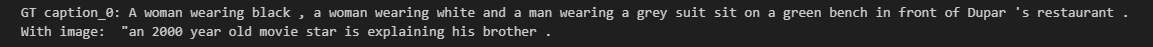

这条 GT caption_0 是数据集给的参考描述（标准答案），说明图片里是三个人坐在餐馆前的长椅上。

而 With image 是你这个“只训练 projector 的极简 VLM”生成的结果：它已经学会了“按 caption 风格续写一句话”，但语义对齐还不稳，所以会出现和图片内容不相关的胡编（说明目前更多学到的是生成格式，而非准确 grounding）

## Cell 12：核心 Ablation（With image vs LLM only）
课堂最重要的对照：  
- 同一个 PROMPT  
- 只改变：是否注入视觉前缀 token

In [24]:
print("With image:", vlm_greedy_answer(img, "", max_new_tokens=24))
print("LLM only :", llm_only_answer("", max_new_tokens=24))

With image:  "A large dog is sitting on a large dog who is laying on a large dog that is laying on a large dog
LLM only :  I know I have had a lot of experiences that made me realize that I need to change my life. I have had


### 解释说明

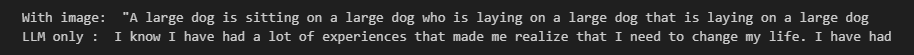

With image 的输出虽然明显是“图像描述/caption 风格”，但出现了“dog 递归复读”的模式，说明视觉前缀确实改变了生成分布，但在小数据/只训 projector 下容易退化为重复模板。

LLM only 则完全偏向纯语言自述，和图像无关，用来对照证明：没有视觉前缀时，模型只能依赖语言先验随意续写。